In [117]:
import random

In [118]:
import numpy as np
import pandas as pd
from pycaret.regression import get_config
from pycaret.regression import set_config
from pycaret.regression import (
    setup,
    compare_models,
    create_model,
    tune_model,
    ensemble_model,
    models,
    blend_models,
    stack_models,
    plot_model,
    evaluate_model,
    interpret_model,
    automl,
    predict_model,
    save_model,
    load_model,
    convert_model,
    create_api,
    create_docker
)
from pycaret.utils import version
from yellowbrick.regressor import CooksDistance

In [119]:
loaded_bestmodel_meta = load_model('../best-model')
loaded_bestmodel_other = load_model('../predict_ws_from_other/best-model-other')

Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded


In [120]:
id_cols = ['productID',"name","pProductID", "wine_url","pageName","uploadDate"]
target_cols = ['WS']
categorical_cols=[
    "description", "productPrice", "productCompetitiveIntensity", "ProductAvailability", "priceCurrency", 	"additionalType" ,"productOrigin", "productVarietal", "productRegion"
]
extra_cols=["shippingRegion", "shipToState"]
other_ratings = [ 'JS', 'WW', 'D', 'BH', 'W&S', 'WE', 'RP', 'JD', 'SJ', 'V', 'CG', 'TP' ]
predictors = [
    'productStock',
    'price',
    'prodAlcoholPercent_percent'
    #'averageRating_bestRating',
    #'averageRating_worstRating',
    #'bestRating',
    #'worstRating',
    #'prodAlcoholVolume_text',
]
model_columns = ['ws_pred_meta','ws_pred_other']

In [121]:
print(f"pycaret version = {version()}")
print("1. Loading Dataset")
df = pd.read_csv("../wine_spectator.csv")
df = df.drop_duplicates('wine_url') 

pycaret version = 3.0.3
1. Loading Dataset


In [122]:
df['ws_pred_meta'] = loaded_bestmodel_meta.predict(df[predictors])

In [123]:
df['ws_pred_other'] = loaded_bestmodel_other.predict(df[other_ratings])

In [63]:
unnamed_cols=df.filter(regex="Unnamed")
df = df.drop(categorical_cols, axis=1)
df = df.drop(extra_cols, axis=1)
df = df.drop(unnamed_cols, axis=1)
df = df.drop(predictors, axis=1)

df = df[id_cols+model_columns+target_cols]
indices = list(df.index)
n_samples = len(indices)
train_samples = int(0.8 * n_samples)
test_samples = n_samples - train_samples
print(f"train_samples = {train_samples}")
print(f"test_samples = {test_samples}")
random.shuffle(indices)
pick_k_random_indices = random.sample(indices, train_samples)
not_picked_indices = set(indices).difference(pick_k_random_indices)
df_train = df.loc[pick_k_random_indices, :]
df_train = df_train.dropna(subset=target_cols, axis=0)
df_train_id = df_train[id_cols]
df_train = df_train.drop(id_cols, axis=1)

train_samples = 1680
test_samples = 420


In [64]:
df_test = df.loc[not_picked_indices, :]
df_test_id = df_test[id_cols]
df_test_truth = df_test[target_cols]
df_test = df_test.drop(id_cols, axis=1)
df_test = df_test.drop(target_cols, axis=1)

In [65]:
print(list(df.describe()))

['productID', 'ws_pred_meta', 'ws_pred_other', 'WS']


CooksDistance(ax=<Axes: >)

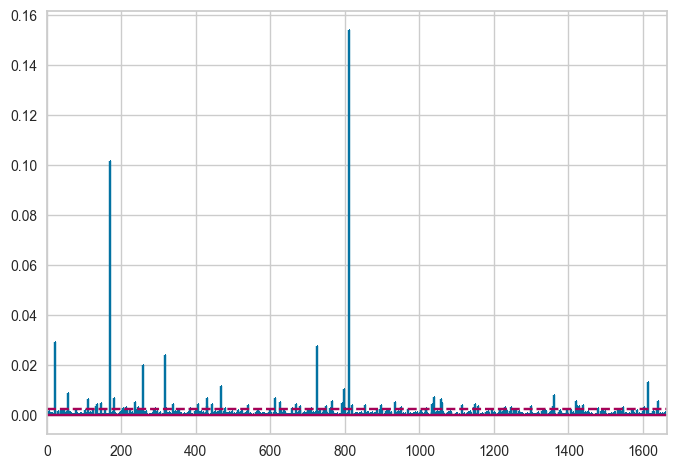

In [66]:
visualizer = CooksDistance()
visualizer.fit(df_train[model_columns], df_train["WS"])
#visualizer.show()

In [68]:
df_train['cooks'] = visualizer.distance_
high_influence = df_train['cooks']>1.0
#high_price = df_train['price']>500

In [70]:
df_train = df_train[~high_influence]
df_train = df_train.drop('cooks',axis=1)

In [73]:
df_train_id = df_train_id[~high_influence]

In [74]:
print("2. Initialize Setup")
reg1 = setup(
    data=df_train,
    target="WS",
    experiment_name='ws_from_meta',
    imputation_type='iterative',    
)

2. Initialize Setup


,Description,Value
0,Session id,3718
1,Target,WS
2,Target type,Regression
3,Original data shape,"(1664, 3)"
4,Transformed data shape,"(1664, 3)"
5,Transformed train set shape,"(1164, 3)"
6,Transformed test set shape,"(500, 3)"
7,Numeric features,2
8,Preprocess,True
9,Imputation type,iterative


In [75]:
print("3. Compare Baseline")

best_model = compare_models(fold=5)

3. Compare Baseline


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.9944,1.5817,1.2546,0.6130,0.0134,0.0107,0.1420
lr,Linear Regression,0.9933,1.5834,1.2554,0.6109,0.0134,0.0107,0.6660
ridge,Ridge Regression,0.9934,1.5833,1.2554,0.6109,0.0134,0.0107,0.0560
lar,Least Angle Regression,0.9933,1.5834,1.2554,0.6109,0.0134,0.0107,0.0560
br,Bayesian Ridge,0.9935,1.5833,1.2554,0.6109,0.0134,0.0107,0.0520
huber,Huber Regressor,0.9883,1.5927,1.2588,0.6081,0.0134,0.0107,0.0620
ada,AdaBoost Regressor,1.0250,1.6269,1.2726,0.6018,0.0136,0.0111,0.0700
lightgbm,Light Gradient Boosting Machine,1.0550,1.7679,1.3276,0.5657,0.0142,0.0114,0.0840
knn,K Neighbors Regressor,1.0640,1.7890,1.3353,0.5609,0.0143,0.0115,0.0480
omp,Orthogonal Matching Pursuit,1.0658,1.8237,1.3476,0.5533,0.0143,0.0115,0.0480


In [76]:
print("4. Create Model")
lr = create_model('lr')
lr = tune_model(lr, n_iter=5, optimize='RMSE')
evaluate_model(lr)

4. Create Model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.8601,1.2564,1.1209,0.6820,0.0119,0.0093
1,0.8452,1.1795,1.0860,0.6328,0.0116,0.0091
2,1.0904,1.9486,1.3959,0.4037,0.0148,0.0118
3,1.0127,1.5674,1.2520,0.5947,0.0134,0.0110
4,0.9833,1.5610,1.2494,0.6673,0.0134,0.0106
5,0.9464,1.4052,1.1854,0.5807,0.0127,0.0102
6,1.0475,1.6642,1.2900,0.6795,0.0137,0.0113
7,1.0107,1.6800,1.2961,0.5171,0.0138,0.0109
8,1.0172,1.6523,1.2854,0.6728,0.0137,0.0110


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.8601,1.2564,1.1209,0.6820,0.0119,0.0093
1,0.8452,1.1795,1.0860,0.6328,0.0116,0.0091
2,1.0904,1.9486,1.3959,0.4037,0.0148,0.0118
3,1.0127,1.5674,1.2520,0.5947,0.0134,0.0110
4,0.9833,1.5610,1.2494,0.6673,0.0134,0.0106
5,0.9464,1.4052,1.1854,0.5807,0.0127,0.0102
6,1.0475,1.6642,1.2900,0.6795,0.0137,0.0113
7,1.0107,1.6800,1.2961,0.5171,0.0138,0.0109
8,1.0172,1.6523,1.2854,0.6728,0.0137,0.0110


Fitting 10 folds for each of 2 candidates, totalling 20 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [77]:
rf = create_model('rf')
rf = tune_model(rf, n_iter=5, optimize='RMSE')
evaluate_model(rf)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.9037,1.3130,1.1459,0.6677,0.0122,0.0097
1,0.9306,1.4121,1.1883,0.5604,0.0127,0.0101
2,1.2045,2.2053,1.4850,0.3251,0.0158,0.0130
3,1.0085,1.5682,1.2523,0.5945,0.0134,0.0109
4,1.0442,1.8455,1.3585,0.6066,0.0145,0.0113
5,1.0252,1.5730,1.2542,0.5307,0.0134,0.0111
6,1.0734,1.9078,1.3812,0.6326,0.0147,0.0116
7,1.2147,2.2963,1.5154,0.3399,0.0162,0.0131
8,1.0698,1.9791,1.4068,0.6081,0.0151,0.0116


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.7841,1.1801,1.0863,0.7013,0.0116,0.0085
1,0.8181,1.1949,1.0931,0.6280,0.0117,0.0089
2,1.0661,1.8200,1.3491,0.4430,0.0144,0.0115
3,0.9831,1.4759,1.2148,0.6184,0.0130,0.0107
4,0.9393,1.5597,1.2489,0.6675,0.0134,0.0102
5,0.8928,1.2305,1.1093,0.6329,0.0119,0.0097
6,1.0051,1.5762,1.2555,0.6964,0.0133,0.0108
7,1.0169,1.7028,1.3049,0.5105,0.0139,0.0110
8,0.9885,1.6602,1.2885,0.6712,0.0138,0.0107


Fitting 10 folds for each of 5 candidates, totalling 50 fits


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [78]:
knn=create_model('knn')
knn = tune_model(knn, n_iter=5, optimize='RMSE')
evaluate_model(knn)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.9060,1.3388,1.1571,0.6612,0.0123,0.0098
1,1.0034,1.5730,1.2542,0.5103,0.0134,0.0109
2,1.1316,2.0581,1.4346,0.3702,0.0153,0.0122
3,1.0564,1.5809,1.2573,0.5912,0.0134,0.0114
4,0.9828,1.5697,1.2529,0.6654,0.0134,0.0106
5,0.9586,1.4931,1.2219,0.5545,0.0131,0.0104
6,1.0655,1.7752,1.3324,0.6581,0.0142,0.0115
7,1.2052,2.2590,1.5030,0.3507,0.0161,0.0130
8,1.1155,1.9610,1.4004,0.6116,0.0150,0.0121


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.8385,1.1844,1.0883,0.7002,0.0116,0.0090
1,0.8863,1.2484,1.1173,0.6113,0.0119,0.0096
2,1.0513,1.7619,1.3274,0.4608,0.0141,0.0114
3,1.0038,1.5087,1.2283,0.6099,0.0131,0.0109
4,0.9534,1.5534,1.2464,0.6689,0.0133,0.0103
5,0.9082,1.3289,1.1528,0.6035,0.0123,0.0098
6,1.0560,1.6642,1.2900,0.6795,0.0137,0.0114
7,1.0241,1.7201,1.3115,0.5056,0.0140,0.0111
8,0.9832,1.6109,1.2692,0.6810,0.0136,0.0107


Fitting 10 folds for each of 5 candidates, totalling 50 fits


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [79]:
print("5. Tune Hyperparameters")
lightgbm = create_model('lightgbm')
lightgbm = tune_model(lightgbm, n_iter=5, optimize='MAE')
evaluate_model(lightgbm)

5. Tune Hyperparameters


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.9050,1.3453,1.1599,0.6595,0.0123,0.0097
1,0.9878,1.5300,1.2369,0.5237,0.0132,0.0107
2,1.1529,2.0486,1.4313,0.3731,0.0152,0.0125
3,0.9912,1.4873,1.2196,0.6154,0.0130,0.0107
4,1.0140,1.8007,1.3419,0.6162,0.0143,0.0109
5,1.0084,1.5518,1.2457,0.5370,0.0133,0.0109
6,1.0190,1.7006,1.3041,0.6725,0.0139,0.0110
7,1.1684,2.1741,1.4745,0.3750,0.0158,0.0126
8,0.9911,1.6406,1.2809,0.6751,0.0137,0.0108


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.8656,1.2873,1.1346,0.6742,0.0121,0.0093
1,0.8835,1.3046,1.1422,0.5938,0.0122,0.0096
2,1.0861,1.7733,1.3317,0.4573,0.0142,0.0117
3,1.0310,1.5982,1.2642,0.5867,0.0135,0.0112
4,0.9844,1.6711,1.2927,0.6438,0.0138,0.0106
5,0.9263,1.3336,1.1548,0.6021,0.0123,0.0100
6,1.0302,1.6756,1.2944,0.6773,0.0138,0.0111
7,1.0746,1.7962,1.3402,0.4837,0.0143,0.0116
8,0.9899,1.6376,1.2797,0.6757,0.0137,0.0108


Fitting 10 folds for each of 5 candidates, totalling 50 fits


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [81]:
print("6. Ensemble Model")

6. Ensemble Model


In [82]:
dt = create_model('dt')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.2393,2.8120,1.6769,0.2884,0.0179,0.0133
1,1.1453,2.3077,1.5191,0.2816,0.0162,0.0124
2,1.3333,3.1111,1.7638,0.0479,0.0188,0.0144
3,1.2393,2.5214,1.5879,0.3480,0.0171,0.0134
4,1.2759,2.9310,1.7120,0.3752,0.0183,0.0138
5,1.3707,2.9052,1.7045,0.1332,0.0182,0.0148
6,1.4397,3.4397,1.8546,0.3375,0.0197,0.0155
7,1.5172,3.6379,1.9073,-0.0457,0.0204,0.0164
8,1.4310,3.9138,1.9783,0.2249,0.0211,0.0156


In [83]:
bagged_dt = ensemble_model(dt, n_estimators=50)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.8991,1.3091,1.1442,0.6687,0.0122,0.0097
1,0.9412,1.4443,1.2018,0.5504,0.0128,0.0102
2,1.2188,2.2740,1.5080,0.3041,0.0161,0.0132
3,1.0092,1.5704,1.2532,0.5939,0.0134,0.0110
4,1.0383,1.8326,1.3537,0.6094,0.0145,0.0112
5,1.0364,1.5728,1.2541,0.5307,0.0134,0.0112
6,1.0824,1.9374,1.3919,0.6269,0.0148,0.0117
7,1.2228,2.3109,1.5202,0.3357,0.0162,0.0132
8,1.0640,1.9809,1.4075,0.6077,0.0151,0.0116


In [84]:
boosted_dt = ensemble_model(dt, method='Boosting')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1.0085,1.8803,1.3713,0.5241,0.0146,0.0108
1,1.0855,1.9573,1.3990,0.3907,0.0150,0.0117
2,1.3162,3.0598,1.7492,0.0636,0.0187,0.0142
3,1.0513,2.0769,1.4412,0.4630,0.0154,0.0114
4,1.2672,3.0086,1.7345,0.3587,0.0185,0.0137
5,1.1379,2.1897,1.4797,0.3467,0.0158,0.0123
6,1.1810,2.4569,1.5674,0.5268,0.0167,0.0128
7,1.2931,2.9138,1.7070,0.1624,0.0182,0.0140
8,1.1638,2.5259,1.5893,0.4998,0.0170,0.0126


In [85]:
print("7. Blend Models")

7. Blend Models


In [86]:
list(models().index)

['lr',
 'lasso',
 'ridge',
 'en',
 'lar',
 'llar',
 'omp',
 'br',
 'ard',
 'par',
 'ransac',
 'tr',
 'huber',
 'kr',
 'svm',
 'knn',
 'dt',
 'rf',
 'et',
 'ada',
 'gbr',
 'mlp',
 'lightgbm',
 'dummy']

In [87]:
top_five = compare_models(n_select=5, fold=5, include=list(models().index))

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
svm,Support Vector Regression,0.9685,1.5383,1.2374,0.6228,0.0132,0.0105,0.0820
gbr,Gradient Boosting Regressor,0.9944,1.5817,1.2546,0.6130,0.0134,0.0107,0.1000
ridge,Ridge Regression,0.9934,1.5833,1.2554,0.6109,0.0134,0.0107,0.0740
lar,Least Angle Regression,0.9933,1.5834,1.2554,0.6109,0.0134,0.0107,0.0660
br,Bayesian Ridge,0.9935,1.5833,1.2554,0.6109,0.0134,0.0107,0.0760
ard,Automatic Relevance Determination,0.9935,1.5834,1.2554,0.6109,0.0134,0.0107,0.0760
lr,Linear Regression,0.9933,1.5834,1.2554,0.6109,0.0134,0.0107,0.0660
tr,TheilSen Regressor,0.9886,1.5866,1.2565,0.6099,0.0134,0.0107,0.5200
huber,Huber Regressor,0.9883,1.5927,1.2588,0.6081,0.0134,0.0107,0.0760
ada,AdaBoost Regressor,1.0250,1.6269,1.2726,0.6018,0.0136,0.0111,0.0780


In [88]:
blender = blend_models(estimator_list=top_five)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.8223,1.1785,1.0856,0.7018,0.0116,0.0089
1,0.8472,1.1846,1.0884,0.6312,0.0116,0.0092
2,1.0648,1.7631,1.3278,0.4604,0.0141,0.0115
3,0.9877,1.5119,1.2296,0.6091,0.0131,0.0107
4,0.9519,1.5284,1.2363,0.6742,0.0132,0.0103
5,0.9325,1.3451,1.1598,0.5987,0.0124,0.0101
6,1.0307,1.6202,1.2729,0.6879,0.0135,0.0111
7,1.0027,1.6502,1.2846,0.5257,0.0137,0.0108
8,1.0070,1.6136,1.2703,0.6804,0.0136,0.0109


In [89]:
print("8. Stack Models")

8. Stack Models


In [90]:
stacker = stack_models(estimator_list=top_five)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.8245,1.1742,1.0836,0.7028,0.0115,0.0089
1,0.8593,1.2049,1.0977,0.6249,0.0117,0.0093
2,1.0334,1.6267,1.2754,0.5022,0.0136,0.0112
3,0.9831,1.4946,1.2225,0.6135,0.0131,0.0107
4,0.9701,1.5543,1.2467,0.6687,0.0133,0.0105
5,0.9389,1.3285,1.1526,0.6036,0.0123,0.0102
6,1.0518,1.6586,1.2879,0.6806,0.0137,0.0113
7,1.0206,1.6666,1.2910,0.5210,0.0138,0.0110
8,1.0325,1.6645,1.2902,0.6704,0.0138,0.0112


In [91]:
print("9. Analyze Model")

9. Analyze Model


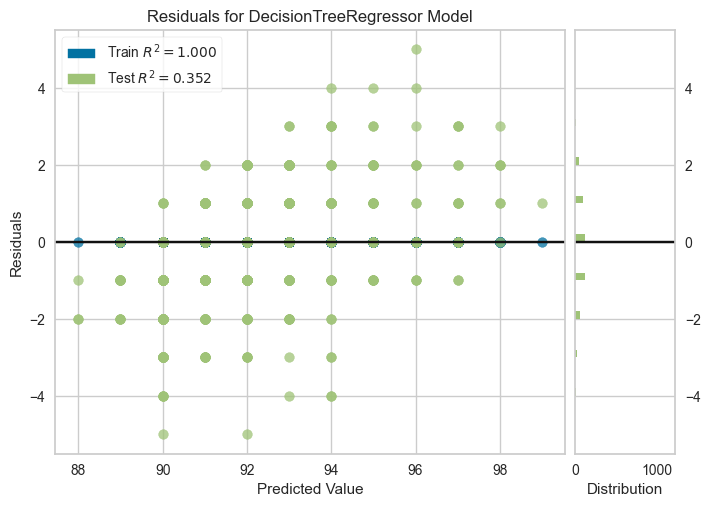

In [92]:
plot_model(dt)

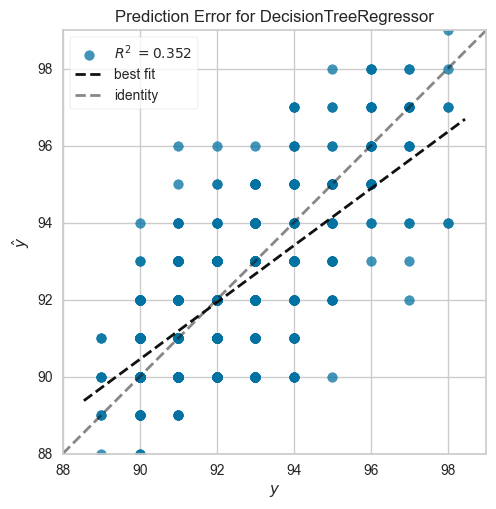

In [93]:
plot_model(dt, plot='error')

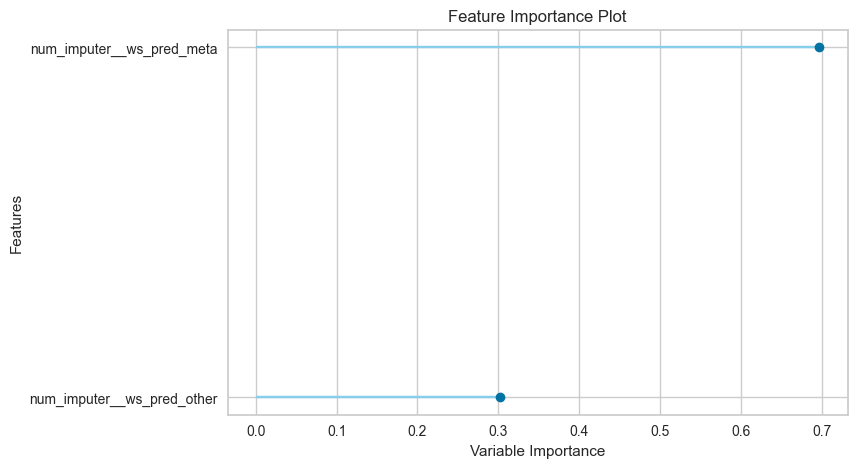

In [94]:
plot_model(dt, plot='feature')

In [95]:
evaluate_model(dt)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [96]:
print("10. Interpret Model")

10. Interpret Model


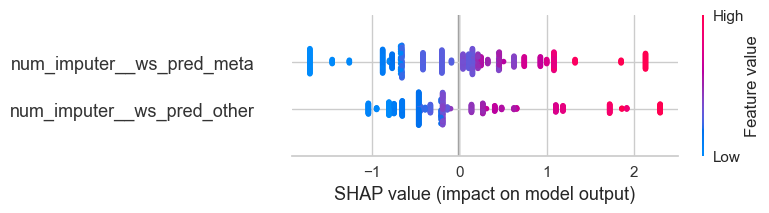

In [97]:
interpret_model(lightgbm)

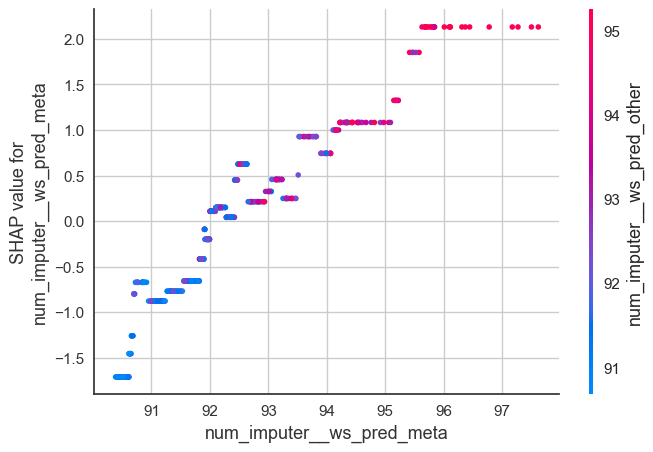

In [98]:
interpret_model(lightgbm, plot='correlation')

In [99]:
interpret_model(lightgbm, plot='reason', observation=12)

In [100]:
print("11. AutoML()")

11. AutoML()


In [101]:
best = automl(optimize='MAE')
print(best)

RandomForestRegressor(bootstrap=False, criterion='absolute_error', max_depth=11,
                      max_features='sqrt', min_impurity_decrease=0.001,
                      min_samples_leaf=6, min_samples_split=5, n_estimators=160,
                      n_jobs=-1, random_state=3718)


In [102]:
print("12. Predict Model")

12. Predict Model


In [103]:
pred_holdouts = predict_model(lightgbm)
pred_holdouts.head()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,0.9026,1.2837,1.1330,0.6664,0.0121,0.0097


,ws_pred_meta,ws_pred_other,WS,prediction_label
926,92.168167,93.397987,94.0,92.892995
1174,90.703842,91.300591,90.0,90.884752
466,91.497643,90.763733,91.0,90.763084
1470,92.735649,91.469925,93.0,92.085734
1180,91.158989,91.469925,90.0,90.994515


In [104]:
predict_new = predict_model(best, data=df_test)
predict_new.head()

,ws_pred_meta,ws_pred_other,prediction_label
2,92.272743,92.695549,92.62500
6,92.279770,92.008720,92.18750
20,90.504547,92.925331,91.50625
25,91.723976,93.119667,91.95625
32,93.175812,94.620644,93.76250


Text(0, 0.5, 'actual WS rating')

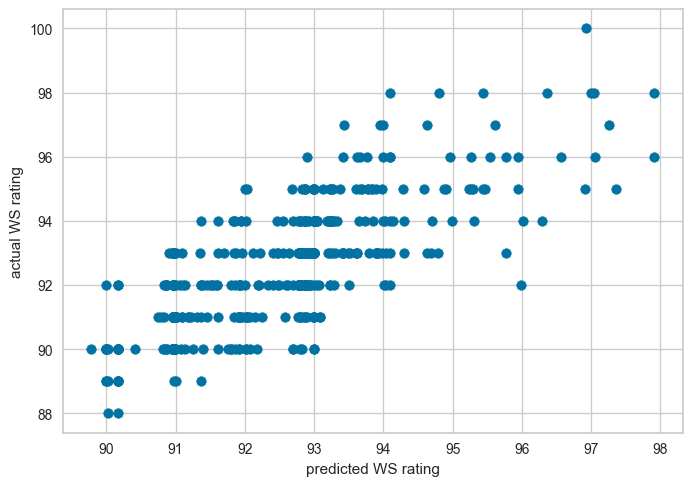

In [105]:
from matplotlib import pyplot as plt
fig = plt.figure()
ax = fig.add_subplot()
ax.scatter(predict_new['prediction_label'],df_test_truth)
ax.set_xlabel('predicted WS rating')
ax.set_ylabel('actual WS rating')

In [110]:
save_model(best, model_name='best-model-ensemble')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=FastMemory(location=/tmp/joblib),
          steps=[('iterative_imputer',
                  TransformerWrapper(transformer=IterativeImputer(cat_estimator=LGBMClassifier(random_state=3718),
                                                                  cat_estimator_prepare_for_categoricals_type=(LGBMClassifier(random_state=3718),
                                                                                                               {}),
                                                                  categorical_indices=[],
                                                                  max_iter=5,
                                                                  num_estimator=LGBMRegressor(random_state=3718),
                                                                  num_estimator_prepare_for_categoricals_type=(LGBMRegressor(random_state=3718),
                                                                                                          

In [112]:
loaded_bestmodel = load_model('best-model-ensemble')
print(loaded_bestmodel)

Transformation Pipeline and Model Successfully Loaded
Pipeline(memory=FastMemory(location=/tmp/joblib),
         steps=[('iterative_imputer',
                 TransformerWrapper(transformer=IterativeImputer(cat_estimator=LGBMClassifier(random_state=3718),
                                                                 cat_estimator_prepare_for_categoricals_type=(LGBMClassifier(random_state=3718),
                                                                                                              {}),
                                                                 categorical_indices=[],
                                                                 max_iter=5,
                                                                 num_estimator=LGBMRegressor(random_state=3718),
                                                                 num_estimator_prepare_for_categoricals_type=(LGBMRegressor(random_state=3718),
                                                             

In [113]:
print(loaded_bestmodel[0])

TransformerWrapper(transformer=IterativeImputer(cat_estimator=LGBMClassifier(random_state=3718),
                                                cat_estimator_prepare_for_categoricals_type=(LGBMClassifier(random_state=3718),
                                                                                             {}),
                                                categorical_indices=[],
                                                max_iter=5,
                                                num_estimator=LGBMRegressor(random_state=3718),
                                                num_estimator_prepare_for_categoricals_type=(LGBMRegressor(random_state=3718),
                                                                                             {}),
                                                random_state=3718,
                                                skip_complete=True))


In [115]:
create_api(best_model,api_name='predict_ws_ensemble')

API successfully created. This function only creates a POST API, it doesn't run it automatically. To run your API, please run this command --> !python predict_ws_ensemble.py


In [116]:
create_docker(api_name='predict_ws_ensemble')

Writing requirements.txt
Writing Dockerfile
Dockerfile and requirements.txt successfully created.
    To build image you have to run --> !docker image build -f "Dockerfile" -t IMAGE_NAME:IMAGE_TAG .
            
